# ノートブック10: 自動ハイパーパラメータチューニング

## 📋 この章で学ぶこと

このノートブックでは、機械学習モデルのハイパーパラメータを体系的に最適化する手法を学びます:

- [ ] ハイパーパラメータとパラメータの違いを理解する
- [ ] GridSearchCVで網羅的な探索ができる
- [ ] RandomizedSearchCVで効率的な探索ができる
- [ ] 複数の評価指標を同時に最適化できる

## 🎯 前提知識

- ✅ Notebook 03（クロスバリデーション）
- ✅ Notebook 07（MLPの基礎）

⏱️ **推定学習時間**: 60分  
📊 **難易度**: ★★★☆☆（中級）  
🎓 **カテゴリ**: 機械学習・モデル最適化

---

## 🚀 なぜハイパーパラメータチューニングが重要なのか？

### モデル性能を左右する「隠れた」要因

機械学習モデルの性能は、**アルゴリズムの選択だけでなく、ハイパーパラメータの設定で大きく変わります**。

```
┌─────────────────────────────────────────────────────────────────────┐
│              ハイパーパラメータの影響度                               │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  同じアルゴリズム（例: Random Forest）でも...                       │
│                                                                     │
│  【デフォルト設定】                                                  │
│    n_estimators=100, max_depth=None                                 │
│    → 精度: 82%                                                      │
│                                                                     │
│  【チューニング後】                                                  │
│    n_estimators=300, max_depth=15, min_samples_leaf=2              │
│    → 精度: 89%  ← 7%向上！                                         │
│                                                                     │
│  これだけの差が生まれる！                                           │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

### Bias-Variance トレードオフとの関係

ハイパーパラメータは、モデルの「複雑さ」を制御します：

```
┌─────────────────────────────────────────────────────────────────────┐
│           ハイパーパラメータと Bias-Variance トレードオフ            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  誤差                                                               │
│   ▲                                                                 │
│   │  ╲                        ╱                                     │
│   │   ╲  Bias（バイアス）   ╱ Variance（分散）                     │
│   │    ╲                  ╱                                         │
│   │     ╲    ╱─────╲    ╱                                          │
│   │      ╲  ╱       ╲  ╱   Total Error                              │
│   │       ╲╱         ╲╱                                             │
│   │        ● ← 最適点                                               │
│   │                                                                 │
│   └──────────────────────────────────────────────────────────▶     │
│              モデルの複雑さ（ハイパーパラメータで制御）               │
│                                                                     │
│  【例: 決定木の max_depth】                                         │
│   - 小さい(3): 単純なモデル → 高Bias, 低Variance → Underfitting   │
│   - 大きい(30): 複雑なモデル → 低Bias, 高Variance → Overfitting   │
│   - 適切(10): バランス → 最適な汎化性能                            │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

### 手動チューニング vs 自動チューニング

```
【手動チューニングの問題】

1回目: alpha=0.01 → 精度 85%
2回目: alpha=0.001 → 精度 87% ← 良くなった！
3回目: alpha=0.0001 → 精度 84% ← 下がった...
4回目: alpha=0.005 → 精度 86%
...
→ 時間がかかる、最適解を見逃す可能性

【自動チューニングのメリット】

✅ 体系的に全ての組み合わせを探索
✅ クロスバリデーションで信頼性の高い評価
✅ 再現性がある（同じコードで同じ結果）
✅ 人間の勘に頼らない
```

---

## セットアップ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, loguniform, randint
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    cross_val_score, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, make_scorer, f1_score
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('whitegrid')
np.random.seed(42)

print("Setup complete!")

# 日本語フォント設定
import matplotlib.font_manager as fm

def setup_japanese_font():
    """日本語フォントを設定する"""
    japanese_fonts = [
        'Hiragino Sans', 'Hiragino Maru Gothic Pro', 'AppleGothic',  # macOS
        'Yu Gothic', 'MS Gothic',  # Windows
        'Noto Sans CJK JP', 'IPAexGothic', 'TakaoPGothic',  # Linux
    ]
    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_used = setup_japanese_font()
if font_used:
    print(f"Japanese font: {font_used}")


C:\Users\yuzup\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Setup complete!
Japanese font: Yu Gothic


---

## 1. ハイパーパラメータとは

### パラメータ vs ハイパーパラメータ

この2つは混同しやすいですが、明確に異なります：

```
┌─────────────────────────────────────────────────────────────────────┐
│              パラメータ vs ハイパーパラメータ                        │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  【パラメータ（学習されるもの）】                                    │
│                                                                     │
│  ニューラルネットワークの場合:                                      │
│    入力 → [W1, b1] → [W2, b2] → 出力                               │
│           ↑           ↑                                             │
│           これらが「パラメータ」                                    │
│                                                                     │
│  - 訓練データから自動的に学習される                                 │
│  - 数千〜数億個存在することも                                       │
│  - 例: 重み(W)、バイアス(b)、決定木の分割点                        │
│                                                                     │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  【ハイパーパラメータ（人間が設定するもの）】                        │
│                                                                     │
│  MLPClassifier(                                                     │
│      hidden_layer_sizes=(100, 50),  ← ハイパーパラメータ           │
│      learning_rate_init=0.001,      ← ハイパーパラメータ           │
│      alpha=0.0001,                  ← ハイパーパラメータ           │
│  )                                                                  │
│                                                                     │
│  - 訓練前に人間が決める                                             │
│  - モデルの「設計図」を決める                                       │
│  - 数個〜数十個程度                                                 │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

### 主要なハイパーパラメータの役割

| モデル | ハイパーパラメータ | 役割 | 大きくすると |
|--------|-------------------|------|-------------|
| **MLP** | hidden_layer_sizes | ネットワーク構造 | 複雑なパターンを学習 |
| | alpha | L2正則化係数 | 過学習を防ぐ |
| | learning_rate_init | 学習率 | 学習が速い（不安定に） |
| **Random Forest** | n_estimators | 木の数 | 精度↑、計算時間↑ |
| | max_depth | 木の深さ | 複雑なパターン、過学習↑ |
| | min_samples_split | 分割の最小サンプル数 | 過学習を防ぐ |
| **SVM** | C | ペナルティ強度 | マージン↓、過学習↑ |
| | gamma | RBFカーネルの広がり | 局所的な学習、過学習↑ |

### ハイパーパラメータの「感度」

```
【感度が高いパラメータ】← 慎重にチューニング
- 学習率 (learning_rate): 1桁変わると結果が大きく変化
- 正則化係数 (alpha, C): モデルの複雑さを直接制御
- カーネル係数 (gamma): SVMの性能に大きく影響

【感度が低いパラメータ】← ある程度の範囲で OK
- 木の数 (n_estimators): 多いほど良いが、収穫逓減
- バッチサイズ (batch_size): 適度な範囲なら影響小
```

In [2]:
# データセットの準備
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=15,
    n_redundant=3,
    n_classes=3,
    n_clusters_per_class=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dataset Information:")
print("="*60)
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {X_train.shape[1]}")
print(f"Classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y_train)}")

Dataset Information:
Training samples: 1600
Test samples: 400
Features: 20
Classes: 3
Class distribution: [536 535 529]


---

## 2. GridSearchCV: 網羅的探索

### GridSearchCVの仕組み

GridSearchCVは、指定されたパラメータグリッドの**すべての組み合わせ**を試します。

```
┌─────────────────────────────────────────────────────────────────────┐
│                    GridSearchCVの動作原理                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  パラメータグリッド:                                                 │
│    alpha: [0.001, 0.01, 0.1]   (3通り)                             │
│    hidden_layer_sizes: [(50,), (100,)]   (2通り)                   │
│                                                                     │
│  → 全組み合わせ = 3 × 2 = 6通り                                     │
│                                                                     │
│  ┌─────────────────────────────────────────────────────────────┐   │
│  │  組み合わせ1: alpha=0.001, hidden=(50,)   → CV実行 → 85.2% │   │
│  │  組み合わせ2: alpha=0.001, hidden=(100,)  → CV実行 → 86.1% │   │
│  │  組み合わせ3: alpha=0.01,  hidden=(50,)   → CV実行 → 87.3% │   │
│  │  組み合わせ4: alpha=0.01,  hidden=(100,)  → CV実行 → 88.5% │ ★ │
│  │  組み合わせ5: alpha=0.1,   hidden=(50,)   → CV実行 → 84.0% │   │
│  │  組み合わせ6: alpha=0.1,   hidden=(100,)  → CV実行 → 83.2% │   │
│  └─────────────────────────────────────────────────────────────┘   │
│                                                                     │
│  さらに 5-fold CV の場合:                                           │
│    6組み合わせ × 5fold = 30回のモデル学習！                         │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

### 組み合わせ爆発問題

```
【パラメータを増やすと...】

2パラメータ × 各3値 = 3² = 9通り
3パラメータ × 各3値 = 3³ = 27通り
4パラメータ × 各3値 = 3⁴ = 81通り
5パラメータ × 各3値 = 3⁵ = 243通り
6パラメータ × 各3値 = 3⁶ = 729通り

5-fold CVなら × 5 = 3,645回のモデル学習！

→ GridSearchCVは「パラメータ数が少ない」場合に有効
```

### GridSearchCVの利点と欠点

| 利点 | 欠点 |
|------|------|
| 確実に最適解を見つける | 計算コストが高い |
| 再現性が完璧 | パラメータ数が増えると非現実的 |
| パラメータ間の相互作用が分かる | 連続値の探索が苦手 |
| 結果の解釈が容易 | グリッド外の最適解を見逃す |

In [3]:
# MLPのパラメータグリッド
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

# 組み合わせ数の計算
total_combinations = 1
for param, values in param_grid_mlp.items():
    total_combinations *= len(values)
    print(f"{param}: {len(values)} options")

print(f"\nTotal combinations: {total_combinations}")
print(f"With 5-fold CV: {total_combinations * 5} model fits")

hidden_layer_sizes: 4 options
activation: 2 options
alpha: 3 options
learning_rate_init: 2 options

Total combinations: 48
With 5-fold CV: 240 model fits


In [4]:
# GridSearchCVの実行
mlp = MLPClassifier(
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

grid_search = GridSearchCV(
    mlp,
    param_grid_mlp,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Starting GridSearchCV...")
grid_search.fit(X_train_scaled, y_train)

print("\n" + "="*60)
print("GRID SEARCH RESULTS")
print("="*60)
print(f"\nBest CV Score: {grid_search.best_score_:.4f}")
print(f"Test Score: {grid_search.score(X_test_scaled, y_test):.4f}")
print(f"\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

Starting GridSearchCV...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

GRID SEARCH RESULTS

Best CV Score: 0.8944
Test Score: 0.9025

Best Parameters:
  activation: relu
  alpha: 0.01
  hidden_layer_sizes: (100,)
  learning_rate_init: 0.01


### 結果の詳細分析

In [5]:
# 結果をDataFrameに変換
results_df = pd.DataFrame(grid_search.cv_results_)

# Top 10の組み合わせ
cols = ['param_hidden_layer_sizes', 'param_activation', 'param_alpha',
        'param_learning_rate_init', 'mean_test_score', 'std_test_score',
        'mean_train_score', 'rank_test_score']
top_results = results_df[cols].sort_values('rank_test_score')

print("\nTop 10 Parameter Combinations:")
print(top_results.head(10).to_string(index=False))


Top 10 Parameter Combinations:
param_hidden_layer_sizes param_activation  param_alpha  param_learning_rate_init  mean_test_score  std_test_score  mean_train_score  rank_test_score
               (100, 50)             relu       0.0100                      0.01         0.894375        0.014170          0.989687                1
                  (100,)             relu       0.0100                      0.01         0.894375        0.014711          0.978594                1
                  (100,)             relu       0.0001                      0.01         0.893750        0.015934          0.975781                3
                  (100,)             relu       0.0010                      0.01         0.892500        0.015637          0.976094                4
                (50, 25)             relu       0.0001                      0.01         0.891250        0.016226          0.978906                5
               (100, 50)             relu       0.0001                    

### パラメータ効果の可視化

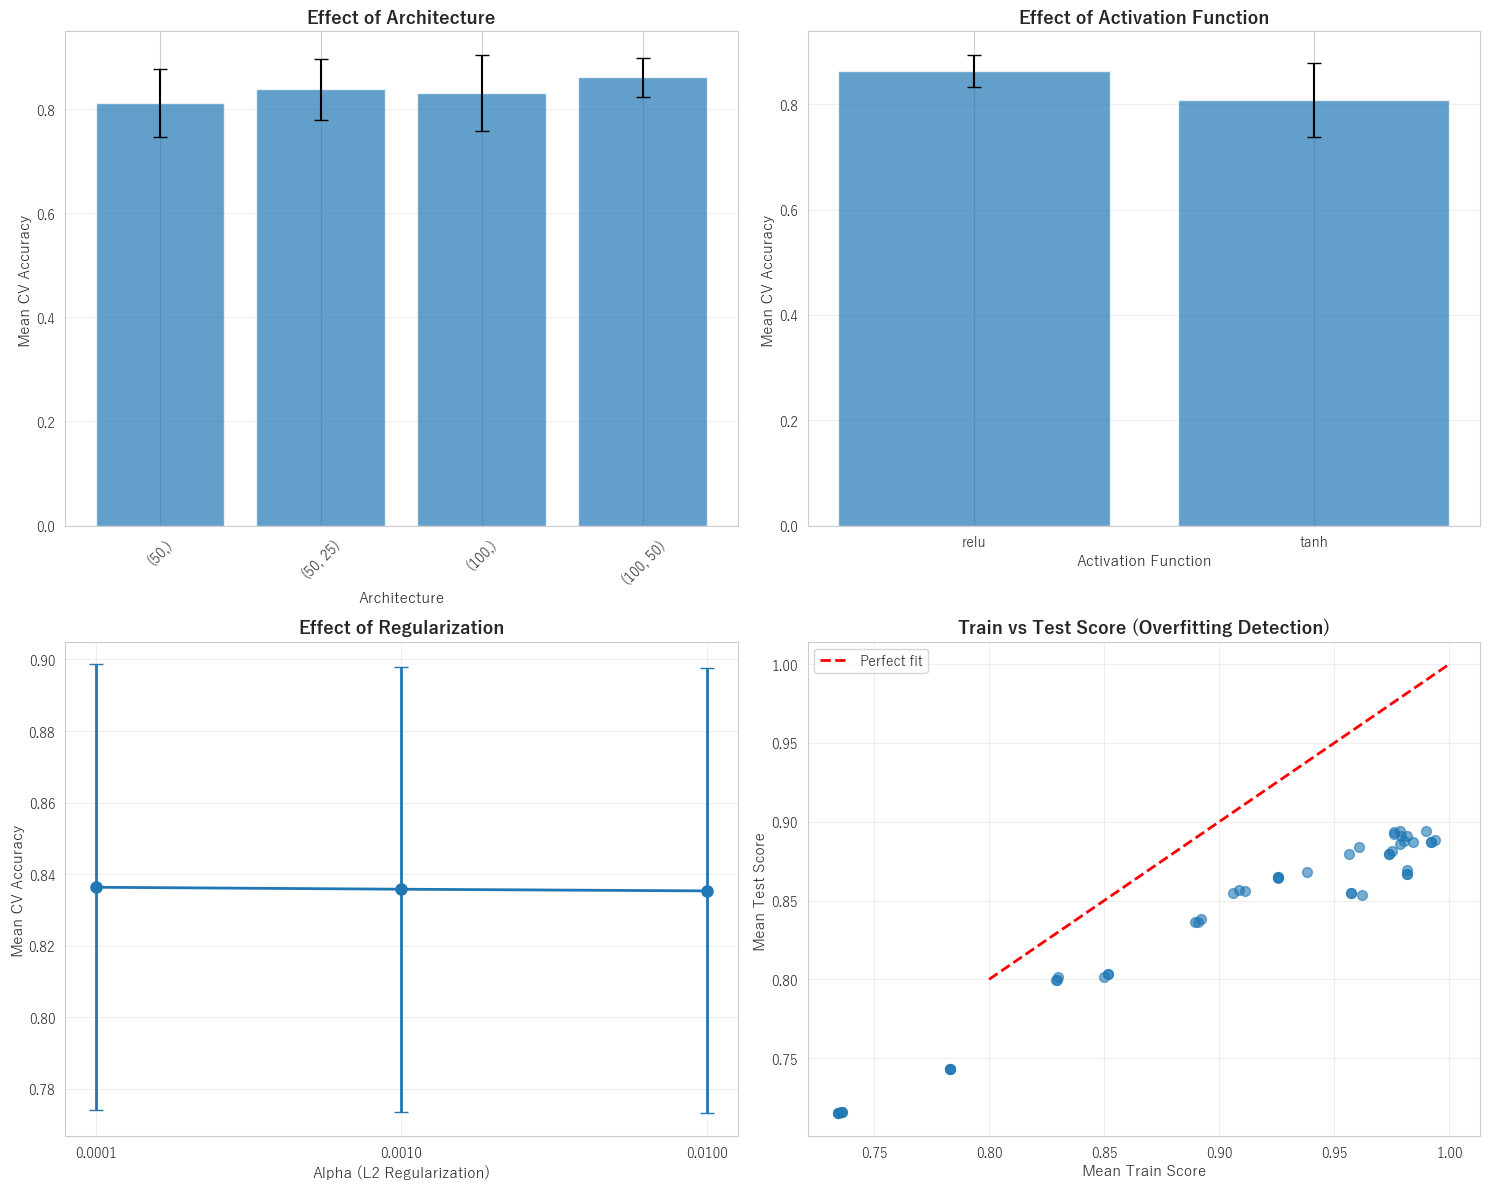


Key Observations:
- Points far from the diagonal line indicate overfitting
- Look for parameters with low variance (more stable)
- Balance between performance and complexity


In [6]:
# GridSearch結果の包括的な可視化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. アーキテクチャの影響
arch_results = results_df.groupby('param_hidden_layer_sizes')['mean_test_score'].agg(['mean', 'std'])
arch_labels = [str(a) for a in arch_results.index]
axes[0, 0].bar(arch_labels, arch_results['mean'], yerr=arch_results['std'], alpha=0.7, capsize=5)
axes[0, 0].set_xlabel('Architecture', fontsize=11)
axes[0, 0].set_ylabel('Mean CV Accuracy', fontsize=11)
axes[0, 0].set_title('Effect of Architecture', fontsize=13, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. 活性化関数の影響
act_results = results_df.groupby('param_activation')['mean_test_score'].agg(['mean', 'std'])
axes[0, 1].bar(act_results.index, act_results['mean'], yerr=act_results['std'], alpha=0.7, capsize=5)
axes[0, 1].set_xlabel('Activation Function', fontsize=11)
axes[0, 1].set_ylabel('Mean CV Accuracy', fontsize=11)
axes[0, 1].set_title('Effect of Activation Function', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Alphaの影響
alpha_results = results_df.groupby('param_alpha')['mean_test_score'].agg(['mean', 'std'])
axes[1, 0].errorbar(range(len(alpha_results)), alpha_results['mean'],
                    yerr=alpha_results['std'], marker='o', markersize=8, capsize=5, linewidth=2)
axes[1, 0].set_xticks(range(len(alpha_results)))
axes[1, 0].set_xticklabels([f'{a:.4f}' for a in alpha_results.index])
axes[1, 0].set_xlabel('Alpha (L2 Regularization)', fontsize=11)
axes[1, 0].set_ylabel('Mean CV Accuracy', fontsize=11)
axes[1, 0].set_title('Effect of Regularization', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Train vs Test (過学習の検出)
axes[1, 1].scatter(results_df['mean_train_score'], results_df['mean_test_score'], 
                   alpha=0.6, s=50)
axes[1, 1].plot([0.8, 1], [0.8, 1], 'r--', lw=2, label='Perfect fit')
axes[1, 1].set_xlabel('Mean Train Score', fontsize=11)
axes[1, 1].set_ylabel('Mean Test Score', fontsize=11)
axes[1, 1].set_title('Train vs Test Score (Overfitting Detection)', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("- Points far from the diagonal line indicate overfitting")
print("- Look for parameters with low variance (more stable)")
print("- Balance between performance and complexity")

---

## 3. RandomizedSearchCV: 効率的な探索

### なぜRandomizedSearchが必要か？

GridSearchCVの「組み合わせ爆発」問題を解決するために、**ランダムサンプリング**で探索します。

```
┌─────────────────────────────────────────────────────────────────────┐
│              GridSearch vs RandomizedSearch                         │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  【GridSearch: 格子状に探索】       【RandomSearch: ランダムに探索】│
│                                                                     │
│  alpha ▲                            alpha ▲                        │
│        │ ● ● ● ● ●                       │     ●   ●              │
│        │ ● ● ● ● ●                       │ ●         ●            │
│        │ ● ● ● ● ●                       │    ●  ●      ●         │
│        │ ● ● ● ● ●                       │  ●       ●             │
│        │ ● ● ● ● ●                       │      ●     ●   ●       │
│        └──────────▶ lr                   └──────────▶ lr           │
│                                                                     │
│  25点すべて評価                     10点をランダムに評価           │
│  計算コスト: 高                     計算コスト: 低                 │
│  最適解を確実に含む                 最適解の「近く」を見つける     │
│                                                                     │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  【重要な洞察】                                                     │
│                                                                     │
│  多くの場合、全パラメータが等しく重要ではない                       │
│  → 一部のパラメータだけが性能に大きく影響                          │
│  → ランダムサンプリングでもその「重要な軸」を探索できる            │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

### 確率分布の活用

RandomizedSearchCVの真の強みは、**連続的な確率分布**からサンプリングできることです。

```
┌─────────────────────────────────────────────────────────────────────┐
│                  確率分布の選び方                                    │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  【uniform(a, b): 一様分布】                                        │
│   - a から b まで均等にサンプリング                                 │
│   - 用途: dropout率(0.1〜0.5)、閾値など                            │
│                                                                     │
│  【loguniform(a, b): 対数一様分布】 ← 最重要！                      │
│   - 対数スケールで均等にサンプリング                                │
│   - 用途: 学習率(0.0001〜0.1)、正則化係数                          │
│                                                                     │
│   なぜ対数スケール？                                                │
│   uniform(0.0001, 0.1) だと:                                        │
│     0.0001〜0.001 の範囲: 10%の確率でしかサンプリングされない      │
│     0.01〜0.1 の範囲: 90%の確率でサンプリングされる                │
│     → 小さい値が十分に探索されない！                               │
│                                                                     │
│   loguniform(0.0001, 0.1) だと:                                     │
│     0.0001〜0.001: 25%                                              │
│     0.001〜0.01: 25%                                                │
│     0.01〜0.1: 25%                                                  │
│     0.1〜1: 25%                                                     │
│     → 各オーダーが均等に探索される！                               │
│                                                                     │
│  【randint(a, b): 整数の一様分布】                                  │
│   - 用途: 木の数(50〜500)、レイヤー数など                          │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

### GridSearch vs RandomizedSearch: いつどちらを使う？

| 状況 | 推奨手法 | 理由 |
|------|---------|------|
| パラメータ2-3個 | GridSearch | 組み合わせ数が管理可能 |
| パラメータ4個以上 | RandomizedSearch | 組み合わせ爆発を回避 |
| 最終調整 | GridSearch | 確実に最適解を見つける |
| 初期探索 | RandomizedSearch | 広い範囲を効率的に探索 |
| 連続パラメータ | RandomizedSearch | loguniformが使える |
| 離散パラメータのみ | GridSearch | グリッドが明確 |

In [7]:
# 連続分布を使ったパラメータ定義
param_distributions = {
    'hidden_layer_sizes': [
        (50,), (100,), (200,),
        (50, 25), (100, 50), (200, 100),
        (100, 50, 25), (200, 100, 50)
    ],
    'activation': ['relu', 'tanh'],
    'alpha': loguniform(1e-5, 1e-1),  # 対数スケール
    'learning_rate_init': loguniform(1e-4, 1e-1),
    'batch_size': [32, 64, 128, 256]
}

print("Parameter Distributions:")
print("="*60)
for param, dist in param_distributions.items():
    if isinstance(dist, list):
        print(f"{param}: {len(dist)} discrete options")
    else:
        print(f"{param}: Continuous distribution")

Parameter Distributions:
hidden_layer_sizes: 8 discrete options
activation: 2 discrete options
alpha: Continuous distribution
learning_rate_init: Continuous distribution
batch_size: 4 discrete options


In [8]:
# RandomizedSearchCVの実行
mlp_random = MLPClassifier(
    solver='adam',
    max_iter=500,
    early_stopping=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    mlp_random,
    param_distributions,
    n_iter=50,  # サンプル数
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

print("Starting RandomizedSearchCV (50 iterations)...")
random_search.fit(X_train_scaled, y_train)

print("\n" + "="*60)
print("RANDOMIZED SEARCH RESULTS")
print("="*60)
print(f"\nBest CV Score: {random_search.best_score_:.4f}")
print(f"Test Score: {random_search.score(X_test_scaled, y_test):.4f}")
print(f"\nBest Parameters:")
for param, value in random_search.best_params_.items():
    if isinstance(value, float):
        print(f"  {param}: {value:.6f}")
    else:
        print(f"  {param}: {value}")

Starting RandomizedSearchCV (50 iterations)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

RANDOMIZED SEARCH RESULTS

Best CV Score: 0.8906
Test Score: 0.8875

Best Parameters:
  activation: tanh
  alpha: 0.000097
  batch_size: 128
  hidden_layer_sizes: (100,)
  learning_rate_init: 0.013703


### RandomizedSearchの探索パターン

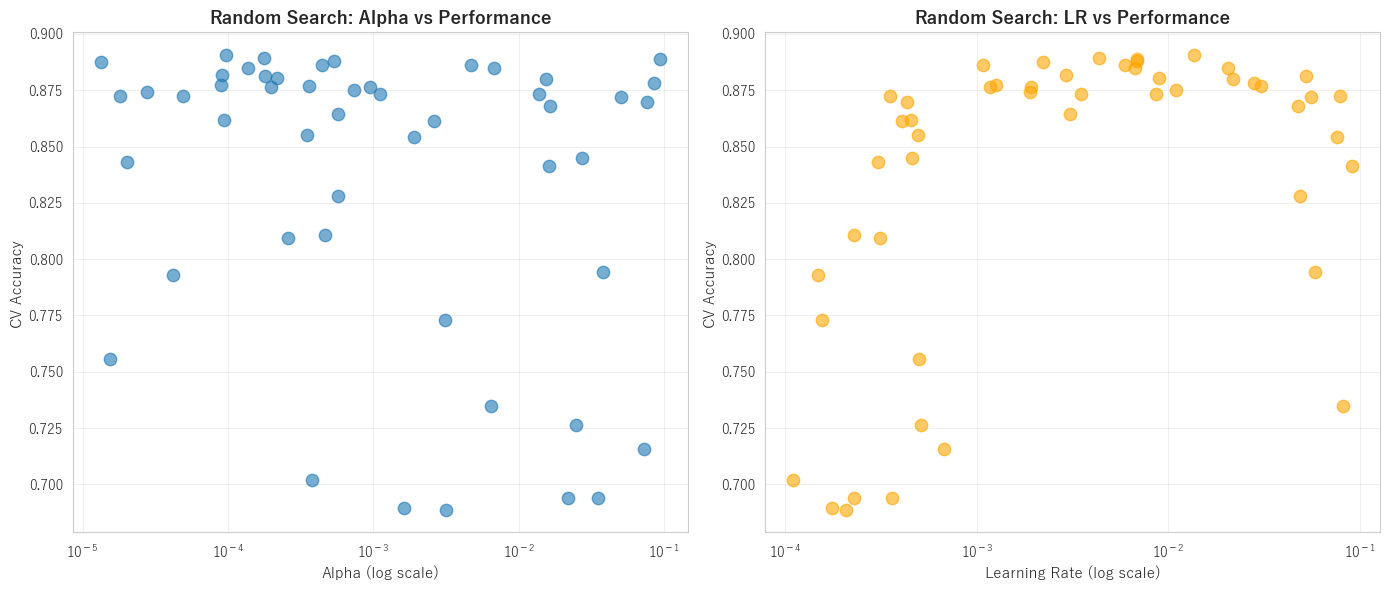


Observations:
- Wide exploration of parameter space
- Log-uniform sampling for learning rate and alpha
- Can find good regions efficiently


In [9]:
# サンプリングされたパラメータの分布
random_results = pd.DataFrame(random_search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Alpha のサンプリング分布
axes[0].scatter(random_results['param_alpha'], random_results['mean_test_score'], 
                alpha=0.6, s=80)
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log scale)', fontsize=11)
axes[0].set_ylabel('CV Accuracy', fontsize=11)
axes[0].set_title('Random Search: Alpha vs Performance', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Learning Rate のサンプリング分布
axes[1].scatter(random_results['param_learning_rate_init'], random_results['mean_test_score'],
                alpha=0.6, s=80, color='orange')
axes[1].set_xscale('log')
axes[1].set_xlabel('Learning Rate (log scale)', fontsize=11)
axes[1].set_ylabel('CV Accuracy', fontsize=11)
axes[1].set_title('Random Search: LR vs Performance', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Wide exploration of parameter space")
print("- Log-uniform sampling for learning rate and alpha")
print("- Can find good regions efficiently")

---

## 4. 複数モデルのチューニング

異なるモデルで最適なハイパーパラメータを探索します。

In [10]:
# Random Forestのチューニング
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Tuning Random Forest...")
rf_search.fit(X_train_scaled, y_train)

print(f"\nRandom Forest Best CV Score: {rf_search.best_score_:.4f}")
print(f"Test Score: {rf_search.score(X_test_scaled, y_test):.4f}")
print(f"\nBest Parameters:")
for param, value in rf_search.best_params_.items():
    print(f"  {param}: {value}")

Tuning Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Random Forest Best CV Score: 0.8400
Test Score: 0.8775

Best Parameters:
  max_depth: 20
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200


In [11]:
# SVMのチューニング
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'poly']
}

svm_search = GridSearchCV(
    SVC(random_state=42),
    svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nTuning SVM...")
svm_search.fit(X_train_scaled, y_train)

print(f"\nSVM Best CV Score: {svm_search.best_score_:.4f}")
print(f"Test Score: {svm_search.score(X_test_scaled, y_test):.4f}")
print(f"\nBest Parameters:")
for param, value in svm_search.best_params_.items():
    print(f"  {param}: {value}")


Tuning SVM...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

SVM Best CV Score: 0.9144
Test Score: 0.9175

Best Parameters:
  C: 1
  gamma: 0.1
  kernel: rbf


### チューニング済みモデルの比較


Tuned Model Comparison:
        Model  CV Mean   CV Std  Test Score
          SVM 0.914375 0.022930      0.9175
   MLP (Grid) 0.894375 0.014711      0.9025
 MLP (Random) 0.890625 0.014790      0.8875
Random Forest 0.840000 0.011592      0.8775


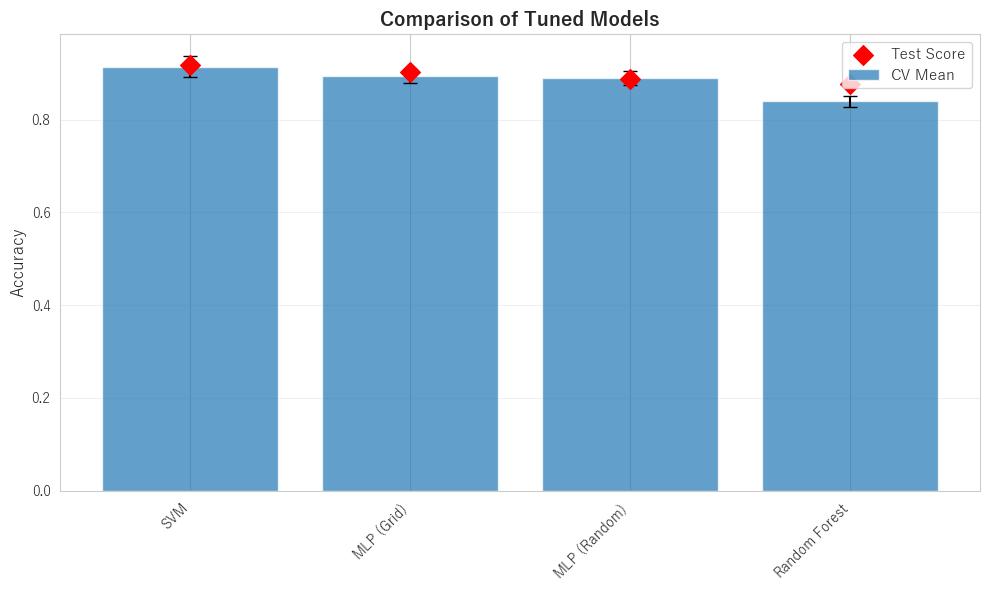

In [12]:
# すべてのチューニング済みモデルを比較
tuned_models = {
    'MLP (Grid)': grid_search.best_estimator_,
    'MLP (Random)': random_search.best_estimator_,
    'Random Forest': rf_search.best_estimator_,
    'SVM': svm_search.best_estimator_
}

comparison_results = []

for name, model in tuned_models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    test_score = model.score(X_test_scaled, y_test)
    
    comparison_results.append({
        'Model': name,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Score': test_score
    })

df_comparison = pd.DataFrame(comparison_results).sort_values('Test Score', ascending=False)

print("\nTuned Model Comparison:")
print("="*60)
print(df_comparison.to_string(index=False))

# 可視化
plt.figure(figsize=(10, 6))
x = np.arange(len(df_comparison))
plt.bar(x, df_comparison['CV Mean'], yerr=df_comparison['CV Std'], 
        alpha=0.7, capsize=5, label='CV Mean')
plt.scatter(x, df_comparison['Test Score'], color='red', s=100, 
            zorder=5, label='Test Score', marker='D')
plt.xticks(x, df_comparison['Model'], rotation=45, ha='right')
plt.ylabel('Accuracy', fontsize=12)
plt.title('Comparison of Tuned Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---

## 5. マルチメトリック最適化

### なぜ複数の指標が必要か？

単一の指標だけでモデルを評価すると、重要な側面を見落とす可能性があります。

```
┌─────────────────────────────────────────────────────────────────────┐
│              単一指標の落とし穴                                      │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  【例: 不正検知システム】                                           │
│                                                                     │
│  不正: 100件、正常: 9,900件（1%が不正）                             │
│                                                                     │
│  モデルA: 「すべて正常」と予測                                      │
│    Accuracy = 9,900/10,000 = 99%  ← 高い！                         │
│    Recall = 0/100 = 0%  ← 不正を1件も検出できない！                 │
│                                                                     │
│  モデルB: バランスの取れた予測                                      │
│    Accuracy = 95%                                                   │
│    Recall = 80%  ← 不正の80%を検出                                  │
│                                                                     │
│  → Accuracyだけ見るとモデルAが良く見えるが、                        │
│    実際にはモデルBの方が有用！                                      │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

### 指標間のトレードオフ

```
┌─────────────────────────────────────────────────────────────────────┐
│              Precision vs Recall トレードオフ                        │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Precision ▲                                                        │
│  (適合率)   │ ●                                                     │
│            │   ●                                                    │
│            │     ●                                                  │
│            │       ●                                                │
│            │         ●                                              │
│            │           ●                                            │
│            └──────────────▶ Recall (再現率)                        │
│                                                                     │
│  【トレードオフの例】                                               │
│                                                                     │
│  厳しい閾値（0.9）:                                                 │
│    - Precision高い（確信度の高いものだけ陽性と判定）                │
│    - Recall低い（多くの陽性を見逃す）                               │
│                                                                     │
│  緩い閾値（0.3）:                                                   │
│    - Precision低い（誤検出が多い）                                  │
│    - Recall高い（陽性をほぼ全て検出）                               │
│                                                                     │
│  → F1スコア = 2 × (Precision × Recall) / (Precision + Recall)      │
│    両者のバランスを取った指標                                       │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

### ビジネス要件に応じた指標選択

| ドメイン | 重視する指標 | 理由 |
|---------|-------------|------|
| **医療診断** | Recall | 病気を見逃すと命に関わる |
| **スパム検出** | Precision | 正常メールをスパム扱いすると困る |
| **不正検知** | F1 / Recall | 不正を見逃すコストが高い |
| **推薦システム** | Precision@K | 上位K件の精度が重要 |
| **一般的な分類** | F1 | バランスの取れた評価 |

In [13]:
# 複数の評価指標を定義
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro'
}

param_grid_multi = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
    'alpha': [0.0001, 0.001, 0.01]
}

mlp_multi = MLPClassifier(
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    random_state=42
)

multi_search = GridSearchCV(
    mlp_multi,
    param_grid_multi,
    cv=5,
    scoring=scoring,
    refit='f1',  # F1スコアで最良モデルを選択
    n_jobs=-1,
    return_train_score=True
)

print("Running multi-metric search...")
multi_search.fit(X_train_scaled, y_train)

print("\nMulti-metric Results:")
print("="*60)

multi_results = pd.DataFrame(multi_search.cv_results_)
for metric in scoring.keys():
    best_idx = multi_results[f'mean_test_{metric}'].idxmax()
    best_score = multi_results.loc[best_idx, f'mean_test_{metric}']  
    best_params = multi_results.loc[best_idx, 'params']
    print(f"\nBest {metric.upper()}:")
    print(f"  Score: {best_score:.4f}")
    print(f"  Parameters: {best_params}")

Running multi-metric search...

Multi-metric Results:

Best ACCURACY:
  Score: 0.8650
  Parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (100, 50)}

Best PRECISION:
  Score: 0.8656
  Parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (100, 50)}

Best RECALL:
  Score: 0.8649
  Parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (100, 50)}

Best F1:
  Score: 0.8645
  Parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (100, 50)}


---

## 6. 実践的なチューニング戦略

### 段階的チューニングアプローチ

実務では、一度に完璧なパラメータを見つけようとせず、**段階的に絞り込む**のが効率的です。

```
┌─────────────────────────────────────────────────────────────────────┐
│                    段階的チューニング戦略                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  【Phase 1: 粗い探索（Coarse Search）】                             │
│                                                                     │
│  目的: 有望な領域を特定する                                         │
│  手法: RandomizedSearchCV (n_iter=30-50)                           │
│  CV: 3-fold（速度重視）                                             │
│  パラメータ範囲: 広め（数オーダー）                                 │
│                                                                     │
│  例: learning_rate in loguniform(1e-5, 1e-1)                       │
│                                                                     │
│                  ↓ 有望な領域を発見                                 │
│                                                                     │
│  【Phase 2: 精密探索（Fine Search）】                               │
│                                                                     │
│  目的: 最適値の近傍を詳しく調べる                                   │
│  手法: GridSearchCV                                                 │
│  CV: 5-fold（信頼性重視）                                           │
│  パラメータ範囲: Phase 1で見つけた領域を密に                       │
│                                                                     │
│  例: learning_rate in [0.005, 0.01, 0.02, 0.05]                    │
│                                                                     │
│                  ↓ 最適値を特定                                     │
│                                                                     │
│  【Phase 3: 最終検証（Final Validation）】                          │
│                                                                     │
│  目的: 選んだパラメータの信頼性を確認                               │
│  手法: ベストパラメータで10-fold CV                                │
│  確認: Train/Testのギャップ（過学習チェック）                       │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

### チューニングの優先順位

すべてのパラメータを同時にチューニングするのは非効率です。**影響度の高いパラメータから**順に調整します。

```
【MLP の場合】
1. hidden_layer_sizes（アーキテクチャ）← 最重要
2. learning_rate_init（学習率）
3. alpha（正則化）
4. batch_size（バッチサイズ）

【Random Forest の場合】
1. n_estimators（木の数）← 最重要
2. max_depth（木の深さ）
3. min_samples_split / min_samples_leaf
4. max_features

【SVM の場合】
1. C（ペナルティ）← 最重要
2. gamma（カーネル係数）
3. kernel（カーネルタイプ）
```

### 計算コストの見積もり

チューニングを始める前に、**計算時間を見積もる**ことが重要です。

```
【計算時間の見積もり公式】

総時間 ≈ 1回の学習時間 × 組み合わせ数 × CV fold数 ÷ 並列数

例:
- 1回の学習: 10秒
- 組み合わせ: 100通り
- 5-fold CV
- 4コア並列 (n_jobs=4)

総時間 ≈ 10 × 100 × 5 ÷ 4 = 1,250秒 ≈ 21分

【時間がかかりすぎる場合の対策】
- n_iter を減らす（RandomizedSearch）
- CV fold数を減らす（3-fold）
- サンプルを減らしてテスト（小さいデータセットで試す）
- n_jobs=-1 で全コア使用
```

In [14]:
print("Hyperparameter Tuning Strategy:")
print("="*60)
print()
print("PHASE 1: COARSE SEARCH")
print("  • Wide parameter ranges")
print("  • Few CV folds (3-fold)")
print("  • Identify promising regions")
print("  • Example: alpha in [0.0001, 0.01, 1]")
print()
print("PHASE 2: REFINED SEARCH")
print("  • Narrow ranges around best values")
print("  • More CV folds (5-fold)")
print("  • Denser grid")
print("  • Example: alpha in [0.001, 0.005, 0.01, 0.05]")
print()
print("PHASE 3: FINE-TUNING")
print("  • Very narrow ranges")
print("  • Full CV (10-fold)")
print("  • Final optimization")
print()
print("BEST PRACTICES:")
print("  ✓ Start simple, increase complexity")
print("  ✓ Use RandomizedSearchCV for initial exploration")
print("  ✓ GridSearchCV for final refinement")
print("  ✓ Monitor train/test gap for overfitting")
print("  ✓ Use log-uniform for learning rates")
print("  ✓ Consider computational budget")
print("  ✓ Document all experiments")

Hyperparameter Tuning Strategy:

PHASE 1: COARSE SEARCH
  • Wide parameter ranges
  • Few CV folds (3-fold)
  • Identify promising regions
  • Example: alpha in [0.0001, 0.01, 1]

PHASE 2: REFINED SEARCH
  • Narrow ranges around best values
  • More CV folds (5-fold)
  • Denser grid
  • Example: alpha in [0.001, 0.005, 0.01, 0.05]

PHASE 3: FINE-TUNING
  • Very narrow ranges
  • Full CV (10-fold)
  • Final optimization

BEST PRACTICES:
  ✓ Start simple, increase complexity
  ✓ Use RandomizedSearchCV for initial exploration
  ✓ GridSearchCV for final refinement
  ✓ Monitor train/test gap for overfitting
  ✓ Use log-uniform for learning rates
  ✓ Consider computational budget
  ✓ Document all experiments


---

## まとめ

### 🎯 このノートブックで学んだこと

```
┌─────────────────────────────────────────────────────────────────────┐
│           ハイパーパラメータチューニング 完全マスターマップ          │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  ① ハイパーパラメータの基礎                                         │
│     └── パラメータとの違い（学習される vs 人間が設定）              │
│     └── Bias-Varianceトレードオフとの関係                           │
│     └── 感度の高いパラメータを優先                                  │
│                                                                     │
│  ② GridSearchCV                                                     │
│     └── 全組み合わせを網羅的に探索                                  │
│     └── パラメータ数が少ない場合に有効                              │
│     └── 確実に最適解を見つける                                      │
│                                                                     │
│  ③ RandomizedSearchCV                                               │
│     └── ランダムサンプリングで効率的に探索                          │
│     └── loguniform分布で学習率・正則化係数を探索                   │
│     └── 大規模パラメータ空間に有効                                  │
│                                                                     │
│  ④ マルチメトリック最適化                                           │
│     └── 複数指標を同時に評価                                        │
│     └── ビジネス要件に応じた指標選択                                │
│     └── Precision/Recallのトレードオフ                              │
│                                                                     │
│  ⑤ 実践的戦略                                                       │
│     └── 段階的チューニング（粗い→精密）                            │
│     └── 計算コストの見積もり                                        │
│     └── 並列化による高速化                                          │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

---

### 📋 クイックリファレンス

#### GridSearchCV テンプレート

```python
from sklearn.model_selection import GridSearchCV

# パラメータグリッドの定義
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

# GridSearchCVの実行
grid_search = GridSearchCV(
    estimator=MLPClassifier(max_iter=500, random_state=42),
    param_grid=param_grid,
    cv=5,                    # 5-fold CV
    scoring='accuracy',      # 評価指標
    n_jobs=-1,              # 全コア使用
    return_train_score=True  # 過学習チェック用
)

grid_search.fit(X_train, y_train)

# 結果の取得
print(f"Best Score: {grid_search.best_score_:.4f}")
print(f"Best Params: {grid_search.best_params_}")
```

#### RandomizedSearchCV テンプレート

```python
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

# パラメータ分布の定義
param_distributions = {
    'hidden_layer_sizes': [(50,), (100,), (200,), (100, 50)],
    'alpha': loguniform(1e-5, 1e-1),        # 対数一様分布
    'learning_rate_init': loguniform(1e-4, 1e-1),
    'batch_size': [32, 64, 128, 256]
}

# RandomizedSearchCVの実行
random_search = RandomizedSearchCV(
    estimator=MLPClassifier(max_iter=500, random_state=42),
    param_distributions=param_distributions,
    n_iter=50,              # サンプル数
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
```

#### マルチメトリック最適化 テンプレート

```python
# 複数の評価指標を定義
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro'
}

multi_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring=scoring,
    refit='f1',  # F1スコアで最良モデルを選択
    n_jobs=-1
)
```

---

### 🔧 ハイパーパラメータ早見表

| モデル | パラメータ | 推奨範囲 | 分布 |
|--------|-----------|---------|------|
| **MLP** | learning_rate_init | 1e-4 〜 1e-1 | loguniform |
| | alpha | 1e-5 〜 1e-1 | loguniform |
| | hidden_layer_sizes | (50,) 〜 (200, 100) | 離散 |
| **Random Forest** | n_estimators | 50 〜 500 | randint |
| | max_depth | 3 〜 30, None | 離散 |
| | min_samples_split | 2 〜 20 | randint |
| **SVM** | C | 1e-2 〜 1e3 | loguniform |
| | gamma | 1e-4 〜 1e1 | loguniform |

---

### ✅ チューニングチェックリスト

#### 事前準備
- [ ] データの前処理完了（スケーリングなど）
- [ ] ベースラインモデルの精度を記録
- [ ] 計算時間の見積もり

#### チューニング実行
- [ ] 最初はRandomizedSearchで広く探索
- [ ] 有望な領域をGridSearchで精密探索
- [ ] return_train_score=Trueで過学習チェック

#### 結果確認
- [ ] Train/Test精度のギャップ確認
- [ ] CV精度の標準偏差確認（安定性）
- [ ] 複数の評価指標を確認

---

### 🔄 手法選択フローチャート

```
パラメータ数は？
    │
    ├── 2-3個 → GridSearchCV（網羅的）
    │
    └── 4個以上 → RandomizedSearchCV（効率的）
                     │
                     └── 有望な領域が見つかったら
                         → GridSearchCVで精密探索
```

---

### 🚀 次のステップ

**Notebook 11: モデル比較と選択** では：
- 複数のモデルを体系的に比較
- 統計的検定による有意差確認
- 最適なモデルの選択方法

**さらに学ぶために**：
- **Optuna**: より高度なハイパーパラメータ最適化
- **Bayesian Optimization**: 効率的な探索アルゴリズム
- **Hyperopt**: 分散ハイパーパラメータ最適化

---

### 🎉 お疲れ様でした！

ハイパーパラメータチューニングは、モデルの性能を引き出す重要なスキルです。
GridSearchCVとRandomizedSearchCVを使い分けて、効率的にチューニングしましょう！